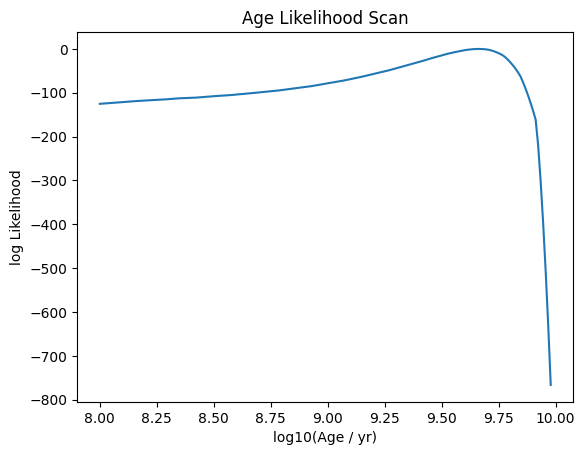

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator
from isochrones.mist import MIST_Isochrone
mist = MIST_Isochrone()

# load MIST grids
age_grid  = np.linspace(6.0, 10.2, 60)     # 1 Myr → 16 Gyr
feh_grid  = np.linspace(-2.5, 0.5, 31)     # halo → super-solar
mass_grid = np.linspace(0.1, 10.0, 200)    # M dwarfs → massive MS

# build the interpolators
bands = ['J_mag', 'H_mag', 'K_mag', 'G_mag', 'BP_mag', 'RP_mag', 'W1_mag', 'W2_mag']
shape = (len(age_grid), len(feh_grid), len(mass_grid))
cubes = {band: np.full(shape, np.nan) for band in bands}

for i, age in enumerate(age_grid):
    for j, feh in enumerate(feh_grid):
        iso = mist.isochrone(age, feh)
        if iso.empty:
            continue
        iso = iso.sort_values('initial_mass')
        for band in bands:
            cubes[band][i, j, :] = np.interp(
                mass_grid,
                iso['initial_mass'],
                iso[band],
                left=np.nan,
                right=np.nan
            )

interpolators = {}
for band in bands:
    interpolators[band] = RegularGridInterpolator(
        (age_grid, feh_grid, mass_grid),
        cubes[band],
        bounds_error=False,
        fill_value=np.nan
    )

compare_bands = ['J_mag','K_mag','G_mag','BP_mag','RP_mag']

def get_model_mag(mass, age, feh):
    mags = []
    for band in compare_bands:
        mags.append(interpolators[band]([[age, feh, mass]])[0])
    return np.array(mags)

# likelihood/prior/post functions
def log_likelihood(theta, y, yerr):
    mass, logage, feh = theta
    model = get_model_mag(mass, logage, feh)
    if model is None or np.any(np.isnan(model)):
        return -np.inf
    sigma_model = 0.05
    total_err = np.sqrt(yerr**2 + sigma_model**2)
    chi2 = np.sum(((y - model) / total_err)**2)
    return -0.5 * chi2

def log_prior(theta):
    mass, logage, feh = theta
    if not (0.1 < mass < 2.0):
        return -np.inf
    if not (7.0 < logage < 10.5):
        return -np.inf
    if not (-2.5 < feh < 0.5):
        return -np.inf
    return 0.0

def log_posterior(theta, y, yerr):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, y, yerr)

# solar data example
iso_sun = mist.isochrone(age=9.66, feh=0.0)
sun = iso_sun.iloc[np.argmin(np.abs(iso_sun['initial_mass'] - 1.0))]
y_dict = {band: sun[band] for band in ['J_mag', 'K_mag', 'G_mag', 'BP_mag', 'RP_mag']}
y = np.array([y_dict[b] for b in ['J_mag', 'K_mag', 'G_mag', 'BP_mag', 'RP_mag']])
yerr = np.full_like(y, 0.02)  # example observational uncertainty

# age scan
def scan_age_likelihood(y, yerr, mass=1.0, feh=0.0):
    ages = np.linspace(8.0, 10.2, 200)
    logL = []
    for a in ages:
        logL.append(log_likelihood([mass, a, feh], y, yerr))
    plt.plot(ages, logL)
    plt.xlabel("log10(Age / yr)")
    plt.ylabel("log Likelihood")
    plt.title("Age Likelihood Scan")
    plt.show()

scan_age_likelihood(y, yerr, mass=1.0, feh=0.0)